# IGRO - gráficos por quadrimestre

Notebook para reproduzir os gráficos quadrimestrais do `IGRO`, do `Subíndice de Tempestividade` e do `Subíndice de Qualidade` a partir das bases do projeto e das fórmulas do modelo ativo.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def encontrar_raiz_projeto(inicio: Path | None = None) -> Path:
    atual = (inicio or Path.cwd()).resolve()
    for candidato in [atual, *atual.parents]:
        if all((candidato / pasta).exists() for pasta in ["06_notebooks", "06_dados", "09_resultados"]):
            return candidato
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto a partir do diretório atual. "
        "Abra o notebook dentro do repositório `igro` ou ajuste manualmente a variável ROOT."
    )


ROOT = encontrar_raiz_projeto()

DADOS_BRUTOS = ROOT / "06_dados" / "01_brutos"
SAIDA = ROOT / "09_resultados" / "exportacoes" / "graficos_quadrimestres_igro"
SAIDA.mkdir(parents=True, exist_ok=True)

INCLUIR_Q2_2026 = False
AQ_FINAL = 20262 if INCLUIR_Q2_2026 else 20261

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

C_BG = "#0b3a45"
C_PANEL = "#f7fafc"
C_TEXT = "#dff8ff"
C_MUTED = "#9fb9c2"
C_GRID = "#d9e7ef"
C_IGRO = "#ef4444"
C_SUBT = "#ef4444"
C_SUBQ = "#ef4444"
C_DOT_FINAL = "#111827"
LIMIAR_ALERTA = 70.0
LIMIAR_META = 90.0
GRID_RATIOS = [1.7, 4.3, 1.2]


In [2]:
PASTAS_DADOS_BRUTOS = [
    ROOT / "06_dados" / "01_brutos",
    ROOT / "02_dados" / "raw",
]


def escolher_arquivo_mais_recente(prefixo: str) -> Path:
    candidatos: list[Path] = []
    pastas_procuradas: list[str] = []
    for pasta in PASTAS_DADOS_BRUTOS:
        pastas_procuradas.append(str(pasta))
        if pasta.exists():
            candidatos.extend(sorted(pasta.glob(f"{prefixo}_*.parquet"), reverse=True))

    if not candidatos:
        candidatos = sorted(ROOT.rglob(f"{prefixo}_*.parquet"), reverse=True)

    erros: list[tuple[str, str]] = []
    for caminho in candidatos:
        try:
            pd.read_parquet(caminho, columns=["Data_manifestacao"]).head(1)
            return caminho
        except Exception as exc:  # pragma: no cover - fallback operacional
            erros.append((str(caminho), repr(exc)))

    raise FileNotFoundError(
        f"Nenhum parquet legível encontrado para {prefixo}. "
        f"Pastas verificadas: {pastas_procuradas}. "
        f"Candidatos encontrados: {len(candidatos)}. "
        f"Erros: {erros}"
    )


ARQ_RELATORIO = escolher_arquivo_mais_recente("relatorio")
ARQ_PESQUISA = escolher_arquivo_mais_recente("pesquisa")
ARQ_INSATISFATORIO = escolher_arquivo_mais_recente("insatisfatorio")

ARQ_RELATORIO, ARQ_PESQUISA, ARQ_INSATISFATORIO

(WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/06_dados/01_brutos/relatorio_2026-05-15.parquet'),
 WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/06_dados/01_brutos/pesquisa_2026-05-15.parquet'),
 WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/06_dados/01_brutos/insatisfatorio_2026-05-15.parquet'))

In [3]:
def carregar_bases() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rel = pd.read_parquet(ARQ_RELATORIO)
    pesq = pd.read_parquet(ARQ_PESQUISA)
    ins = pd.read_parquet(ARQ_INSATISFATORIO)

    for df in (rel, pesq, ins):
        df.columns = [c.lower() for c in df.columns]
        df["data_manifestacao"] = pd.to_datetime(df["data_manifestacao"], errors="coerce")

    return rel, pesq, ins


def rotulo_quadrimestre(datas: pd.Series) -> pd.Series:
    mes = datas.dt.month
    q = np.select([mes <= 4, mes <= 8], [1, 2], default=3)
    return pd.Series(
        [f"Q{quadri}/{ano}" if not pd.isna(ano) else None for quadri, ano in zip(q, datas.dt.year)],
        index=datas.index,
    )


def chave_quadrimestre(datas: pd.Series) -> pd.Series:
    mes = datas.dt.month
    q = np.select([mes <= 4, mes <= 8], [1, 2], default=3)
    return datas.dt.year * 10 + q


def preparar_quadrimestre(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["aq"] = chave_quadrimestre(df["data_manifestacao"])
    df["quadri_label"] = rotulo_quadrimestre(df["data_manifestacao"])
    return df


relatorio, pesquisa, insatisfatorio = carregar_bases()
relatorio = preparar_quadrimestre(relatorio)
pesquisa = preparar_quadrimestre(pesquisa)
insatisfatorio = preparar_quadrimestre(insatisfatorio)

print("Relatório:", len(relatorio), "linhas")
print("Pesquisa:", len(pesquisa), "linhas")
print("Insatisfatório:", len(insatisfatorio), "linhas")

Relatório: 113476 linhas
Pesquisa: 10930 linhas
Insatisfatório: 1654 linhas


## 1. Cálculo da série quadrimestral

A lógica abaixo replica as medidas centrais do modelo ativo em `07_dashboards/powerbi/.../_medidas.tmdl`.

In [4]:
def calcular_serie_quadrimestral(
    rel: pd.DataFrame,
    pesq: pd.DataFrame,
    ins: pd.DataFrame,
    aq_inicial: int = 20241,
    aq_final: int = AQ_FINAL,
) -> pd.DataFrame:
    rel = rel.copy()
    pesq = pesq.copy()
    ins = ins.copy()

    rel["dias_vida"] = pd.to_numeric(rel["dias_vida"], errors="coerce")

    base = (
        rel.groupby(["aq", "quadri_label"], dropna=True)
        .agg(
            total_manifestacoes=("protocolo", "count"),
            qtd_mais_30=("dias_vida", lambda s: (s > 30).sum()),
            tmr=("dias_vida", "mean"),
            qtd_lai=("tipo_manifestacao", lambda s: (s == "L.A.I.").sum()),
        )
        .reset_index()
    )
    base["elegiveis"] = base["total_manifestacoes"] - base["qtd_lai"]
    base["kri1_pct_mais_30"] = base["qtd_mais_30"] / base["total_manifestacoes"]

    resposta = pesquisa["finalizacao"].fillna("").astype(str).str.strip().str.lower()
    pesq["sim"] = (resposta == "sim").astype(int)
    pesq["parcial"] = (resposta == "parcialmente").astype(int)
    pesq["recomendaria"] = pd.to_numeric(pesq["recomendaria"], errors="coerce")

    base_pesquisa = (
        pesq.groupby(["aq", "quadri_label"], dropna=True)
        .agg(
            qtd_pesquisas=("protocolo", "count"),
            qtd_sim=("sim", "sum"),
            qtd_parcial=("parcial", "sum"),
            kri5_nota=("recomendaria", "mean"),
        )
        .reset_index()
    )
    base_pesquisa["kri3_resolutividade"] = (
        base_pesquisa["qtd_sim"] + 0.5 * base_pesquisa["qtd_parcial"]
    ) / base_pesquisa["qtd_pesquisas"]

    base_ins = (
        ins.groupby(["aq", "quadri_label"], dropna=True)
        .agg(qtd_insatisfatorias=("protocolo", "count"))
        .reset_index()
    )

    serie = base.merge(base_pesquisa[["aq", "quadri_label", "qtd_pesquisas", "kri3_resolutividade", "kri5_nota"]], on=["aq", "quadri_label"], how="left")
    serie = serie.merge(base_ins, on=["aq", "quadri_label"], how="left")
    serie["qtd_insatisfatorias"] = serie["qtd_insatisfatorias"].fillna(0)
    serie["kri4_pct_insatisfatorias"] = serie["qtd_insatisfatorias"] / serie["elegiveis"]

    serie["score_kri1"] = ((0.02 - serie["kri1_pct_mais_30"]) / (0.02 - 0.01)).clip(0, 1)
    serie["score_kri2"] = ((10.0 - serie["tmr"]) / (10.0 - 5.0)).clip(0, 1)
    serie["score_kri3"] = ((serie["kri3_resolutividade"] - 0.50) / (0.70 - 0.50)).clip(0, 1)
    serie["score_kri4"] = ((0.035 - serie["kri4_pct_insatisfatorias"]) / (0.035 - 0.025)).clip(0, 1)
    serie["score_kri5"] = ((serie["kri5_nota"] - 6.0) / (8.0 - 6.0)).clip(0, 1)

    serie["sub_t"] = (0.60 * serie["score_kri2"] + 0.40 * serie["score_kri1"]).clip(0, 1)
    serie["sub_q"] = (0.40 * serie["score_kri3"] + 0.30 * serie["score_kri4"] + 0.30 * serie["score_kri5"]).clip(0, 1)
    serie["igro"] = np.where(
        (serie["sub_t"] > 0) & (serie["sub_q"] > 0),
        np.sqrt(serie["sub_t"] * serie["sub_q"]),
        0,
    )

    serie = serie[(serie["aq"] >= aq_inicial) & (serie["aq"] <= aq_final)].sort_values("aq").reset_index(drop=True)
    return serie


serie_quadri = calcular_serie_quadrimestral(relatorio, pesquisa, insatisfatorio)
serie_quadri

,aq,quadri_label,total_manifestacoes,qtd_mais_30,tmr,qtd_lai,elegiveis,kri1_pct_mais_30,qtd_pesquisas,kri3_resolutividade,...,qtd_insatisfatorias,kri4_pct_insatisfatorias,score_kri1,score_kri2,score_kri3,score_kri4,score_kri5,sub_t,sub_q,igro
0,20241,Q1/2024,16368,125,7.180230,0,16368,0.007637,1804,0.575942,...,231,0.014113,1.0,0.563954,0.379712,1.0,0.646341,0.738372,0.645787,0.690530
1,20242,Q2/2024,14264,115,5.753856,0,14264,0.008062,1462,0.583447,...,204,0.014302,1.0,0.849229,0.417237,1.0,0.766416,0.909537,0.696819,0.796105
2,20243,Q3/2024,14945,73,7.190365,0,14945,0.004885,1469,0.594963,...,226,0.015122,1.0,0.561927,0.474813,1.0,0.757318,0.737156,0.71712,0.727069
3,20251,Q1/2025,17354,100,7.056471,0,17354,0.005762,1573,0.561030,...,278,0.016019,1.0,0.588706,0.305149,1.0,0.642085,0.753223,0.614685,0.680438
4,20252,Q2/2025,15856,97,6.297931,0,15856,0.006118,1409,0.572392,...,201,0.012677,1.0,0.740414,0.361959,1.0,0.751597,0.844248,0.670263,0.752242
5,20253,Q3/2025,14915,60,6.352129,0,14915,0.004023,1357,0.553058,...,225,0.015085,1.0,0.729574,0.265291,1.0,0.661017,0.837745,0.604422,0.711583
6,20261,Q1/2026,17903,62,6.028319,0,17903,0.003463,1771,0.502259,...,274,0.015305,1.0,0.794336,0.011293,1.0,0.460474,0.876602,0.44266,0.622925


In [5]:
serie_exportacao = serie_quadri.copy()
for coluna in [
    "igro",
    "sub_t",
    "sub_q",
    "kri1_pct_mais_30",
    "kri3_resolutividade",
    "kri4_pct_insatisfatorias",
    "score_kri1",
    "score_kri2",
    "score_kri3",
    "score_kri4",
    "score_kri5",
]:
    serie_exportacao[coluna] = serie_exportacao[coluna] * 100

serie_exportacao = serie_exportacao.rename(
    columns={
        "quadri_label": "periodo",
        "igro": "igro_pct",
        "sub_t": "sub_t_pct",
        "sub_q": "sub_q_pct",
        "kri1_pct_mais_30": "kri1_pct_mais_30",
        "tmr": "kri2_tmr_dias",
        "kri3_resolutividade": "kri3_resolutividade_pct",
        "kri4_pct_insatisfatorias": "kri4_pct_insatisfatorias",
        "kri5_nota": "kri5_nota_recomendacao",
    }
)
serie_exportacao.round(2)

,aq,periodo,total_manifestacoes,qtd_mais_30,kri2_tmr_dias,qtd_lai,elegiveis,kri1_pct_mais_30,qtd_pesquisas,kri3_resolutividade_pct,...,qtd_insatisfatorias,kri4_pct_insatisfatorias,score_kri1,score_kri2,score_kri3,score_kri4,score_kri5,sub_t_pct,sub_q_pct,igro_pct
0,20241,Q1/2024,16368,125,7.18,0,16368,0.76,1804,57.59,...,231,1.41,100.0,56.40,37.97,100.0,64.63,73.84,64.58,69.05
1,20242,Q2/2024,14264,115,5.75,0,14264,0.81,1462,58.34,...,204,1.43,100.0,84.92,41.72,100.0,76.64,90.95,69.68,79.61
2,20243,Q3/2024,14945,73,7.19,0,14945,0.49,1469,59.50,...,226,1.51,100.0,56.19,47.48,100.0,75.73,73.72,71.71,72.71
3,20251,Q1/2025,17354,100,7.06,0,17354,0.58,1573,56.10,...,278,1.60,100.0,58.87,30.51,100.0,64.21,75.32,61.47,68.04
4,20252,Q2/2025,15856,97,6.30,0,15856,0.61,1409,57.24,...,201,1.27,100.0,74.04,36.20,100.0,75.16,84.42,67.03,75.22
5,20253,Q3/2025,14915,60,6.35,0,14915,0.40,1357,55.31,...,225,1.51,100.0,72.96,26.53,100.0,66.1,83.77,60.44,71.16
6,20261,Q1/2026,17903,62,6.03,0,17903,0.35,1771,50.23,...,274,1.53,100.0,79.43,1.13,100.0,46.05,87.66,44.27,62.29


## 2. Funções de visualização

Os gráficos abaixo seguem a mesma lógica visual do dashboard: linha temporal, zona de atenção abaixo de `70%` e meta visual em `90%`.

In [6]:
def classificar_faixa(valor_pct: float) -> str:
    if valor_pct >= 90:
        return "Controlado"
    if valor_pct >= 70:
        return "Em atenção"
    if valor_pct >= 50:
        return "Elevado"
    return "Crítico"


def cor_faixa(valor_pct: float) -> str:
    if valor_pct >= 90:
        return "#0f766e"
    if valor_pct >= 70:
        return "#b45309"
    if valor_pct >= 50:
        return "#c2410c"
    return "#991b1b"


def quebrar_texto(texto: str, largura: int) -> str:
    return "\n".join(textwrap.wrap(texto, width=largura, break_long_words=False, break_on_hyphens=False))


def plotar_grafico_quadrimestral(df: pd.DataFrame, coluna: str, titulo: str, subtitulo: str, cor_linha: str, nome_arquivo: str) -> Path:
    dados = df[["quadri_label", coluna]].copy()
    dados["valor_pct"] = dados[coluna] * 100
    x = np.arange(len(dados))
    y = dados["valor_pct"].to_numpy()

    fig = plt.figure(figsize=(12.8, 3.9), facecolor=C_BG)
    gs = fig.add_gridspec(1, 3, width_ratios=GRID_RATIOS, wspace=0.14)

    ax_l = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[0, 1])
    ax_r = fig.add_subplot(gs[0, 2])

    for eixo in (ax_l, ax_r):
        eixo.set_facecolor(C_BG)
        eixo.set_xticks([])
        eixo.set_yticks([])
        for spine in eixo.spines.values():
            spine.set_visible(False)

    valor_atual = float(y[-1])
    valor_anterior = float(y[-2]) if len(y) > 1 else np.nan
    delta = valor_atual - valor_anterior if len(y) > 1 else np.nan

    titulo_fmt = quebrar_texto(titulo, 24)
    subtitulo_fmt = quebrar_texto(subtitulo, 32)
    ax_l.text(0.02, 0.97, titulo_fmt, color=C_TEXT, fontsize=12.5, fontweight="bold", va="top", transform=ax_l.transAxes)
    ax_l.text(0.02, 0.84, subtitulo_fmt, color=C_MUTED, fontsize=8.5, va="top", transform=ax_l.transAxes)
    ax_l.text(0.02, 0.40, f"{valor_atual:.1f}%", color=C_TEXT, fontsize=24, fontweight="bold", transform=ax_l.transAxes)
    ax_l.text(0.02, 0.25, f"Último período:\n{dados['quadri_label'].iloc[-1]}", color=C_MUTED, fontsize=9, linespacing=1.4, transform=ax_l.transAxes)

    ax.set_facecolor(C_PANEL)
    ax.axhspan(0, LIMIAR_ALERTA, color="#f59e0b", alpha=0.12)
    ax.axhspan(LIMIAR_META, 100, color="#34d399", alpha=0.10)
    ax.axhline(LIMIAR_ALERTA, color="#f59e0b", linestyle=(0, (4, 3)), linewidth=1.1)
    ax.axhline(LIMIAR_META, color="#34d399", linestyle=(0, (4, 3)), linewidth=1.1)
    ax.plot(x, y, color=cor_linha, linewidth=2)
    ax.scatter(x[:-1], y[:-1], color=cor_linha, edgecolor="white", linewidth=1.4, s=34, zorder=3)
    ax.scatter(x[-1], y[-1], color=C_DOT_FINAL, edgecolor="white", linewidth=1.5, s=38, zorder=4)

    for xi, yi in zip(x, y):
        ax.text(xi, yi + 2.7, f"{yi:.1f}", ha="center", va="bottom", fontsize=7.2, color="#334155", fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(dados["quadri_label"], fontsize=8, color="#475467")
    ax.tick_params(axis="y", labelsize=8, colors="#667085")
    ax.grid(axis="y", color=C_GRID, linewidth=0.8)
    ax.set_ylim(max(0, min(40, y.min() - 8)), min(100, max(95, y.max() + 8)))
    ax.set_xlim(-0.25, len(dados) - 0.75)
    ax.spines["left"].set_color("#dbe7f0")
    ax.spines["bottom"].set_color("#dbe7f0")

    status = classificar_faixa(valor_atual)
    ax_r.text(
        0.98,
        0.88,
        status,
        ha="right",
        va="center",
        fontsize=9,
        color=C_TEXT,
        bbox=dict(boxstyle="round,pad=0.45,rounding_size=0.9", fc=cor_faixa(valor_atual), ec="#d1d5db", lw=0.4),
        transform=ax_r.transAxes,
    )
    if not math.isnan(delta):
        sinal = "+" if delta >= 0 else ""
        cor_delta = "#86efac" if delta >= 0 else "#fca5a5"
        ax_r.text(0.98, 0.45, f"{sinal}{delta:.1f} p.p.\nvs {dados['quadri_label'].iloc[-2]}", ha="right", va="center", fontsize=10, fontweight="bold", color=cor_delta, transform=ax_r.transAxes)
    ax_r.text(0.98, 0.20, "Faixa de atenção abaixo de 70%.\nMeta visual em 90%.", ha="right", va="center", fontsize=8.2, color=C_MUTED, linespacing=1.45, transform=ax_r.transAxes)

    caminho = SAIDA / nome_arquivo
    fig.savefig(caminho, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    plt.close(fig)
    return caminho


## 3. Gráficos principais

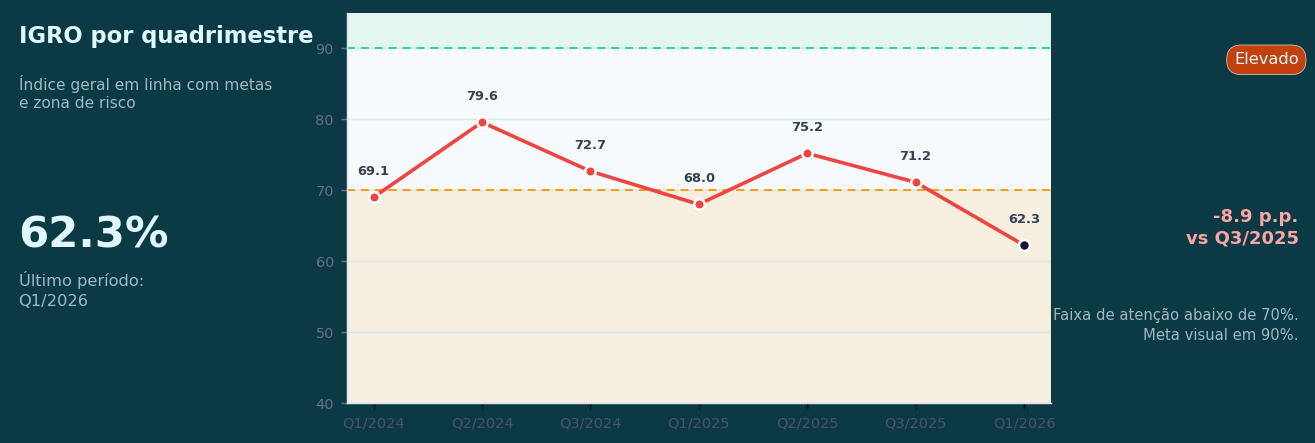

WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/09_resultados/exportacoes/graficos_quadrimestres_igro/igro_por_quadrimestre.png')

In [7]:
arquivo_igro = plotar_grafico_quadrimestral(
    serie_quadri,
    coluna="igro",
    titulo="IGRO por quadrimestre",
    subtitulo="Índice geral em linha com metas e zona de risco",
    cor_linha=C_IGRO,
    nome_arquivo="igro_por_quadrimestre.png",
)
arquivo_igro

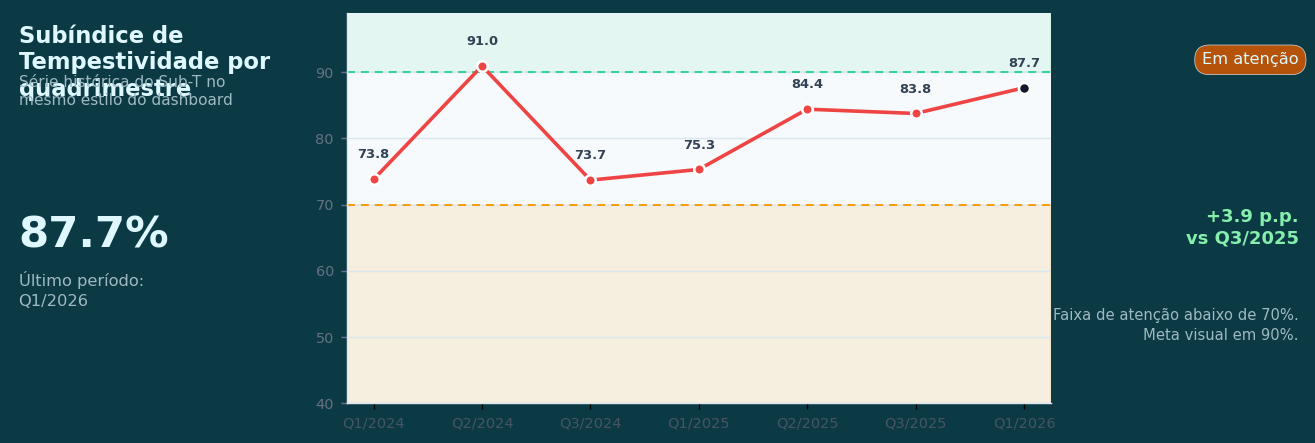

WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/09_resultados/exportacoes/graficos_quadrimestres_igro/subindice_tempestividade_por_quadrimestre.png')

In [8]:
arquivo_subt = plotar_grafico_quadrimestral(
    serie_quadri,
    coluna="sub_t",
    titulo="Subíndice de Tempestividade por quadrimestre",
    subtitulo="Série histórica do Sub-T no mesmo estilo do dashboard",
    cor_linha=C_SUBT,
    nome_arquivo="subindice_tempestividade_por_quadrimestre.png",
)
arquivo_subt

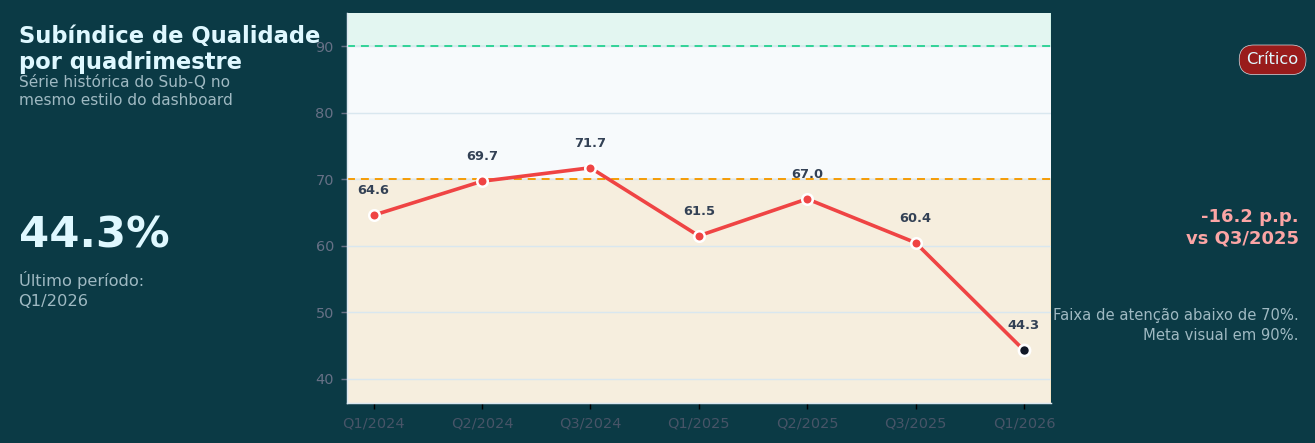

WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/09_resultados/exportacoes/graficos_quadrimestres_igro/subindice_qualidade_por_quadrimestre.png')

In [9]:
arquivo_subq = plotar_grafico_quadrimestral(
    serie_quadri,
    coluna="sub_q",
    titulo="Subíndice de Qualidade por quadrimestre",
    subtitulo="Série histórica do Sub-Q no mesmo estilo do dashboard",
    cor_linha=C_SUBQ,
    nome_arquivo="subindice_qualidade_por_quadrimestre.png",
)
arquivo_subq

## 4. Gráficos dos KRIs

Os cinco gráficos abaixo usam a mesma base quadrimestral, mas com limiares compatíveis com cada indicador do modelo ativo.

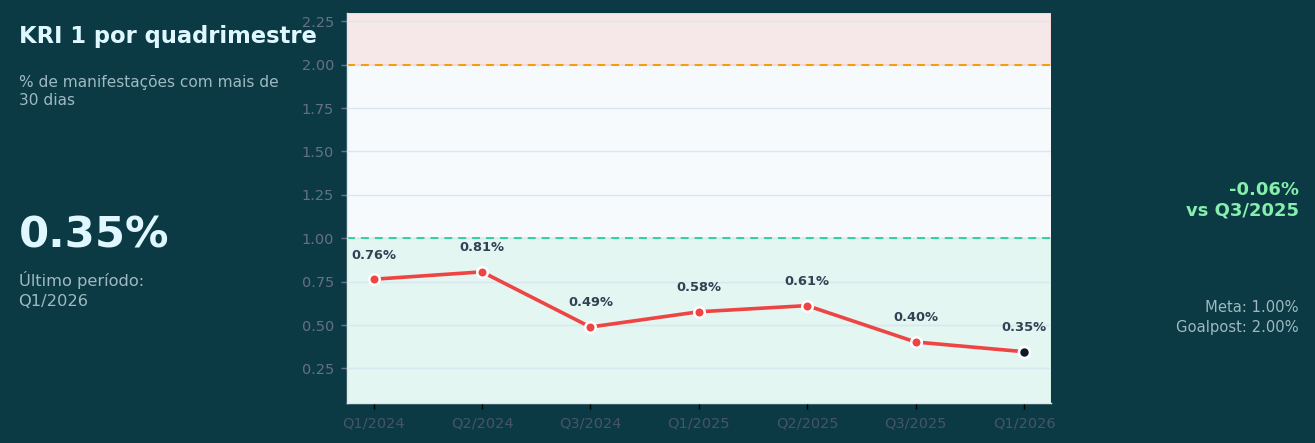

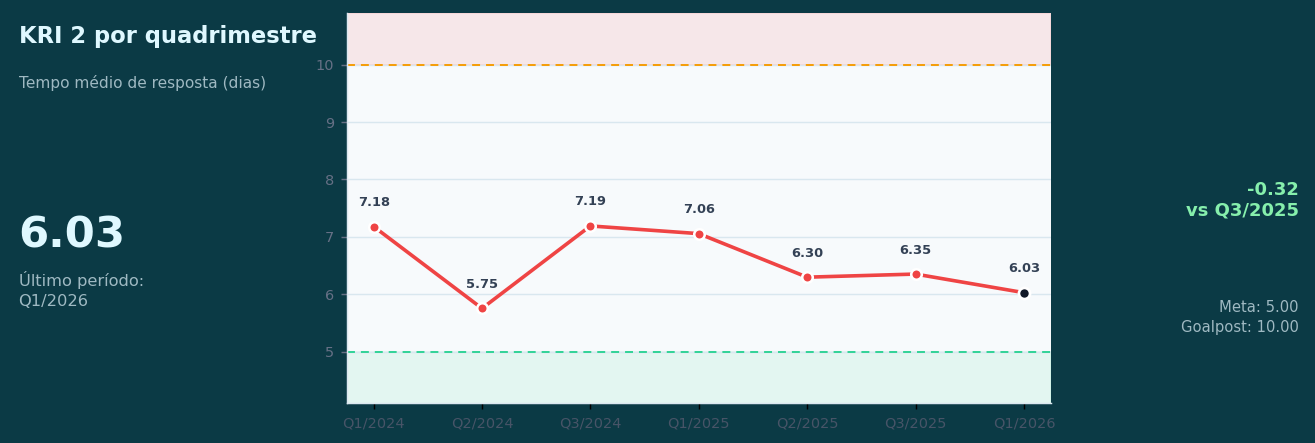

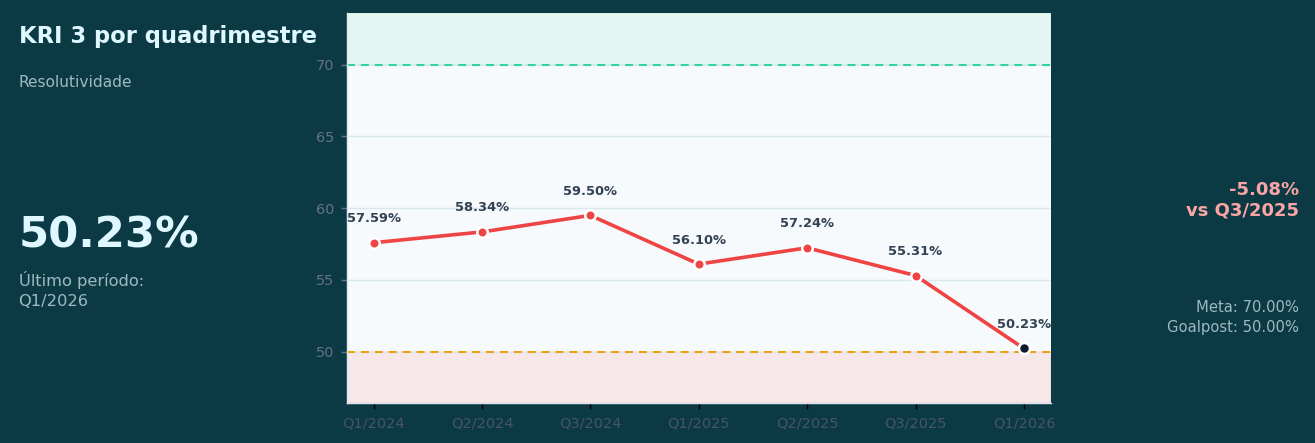

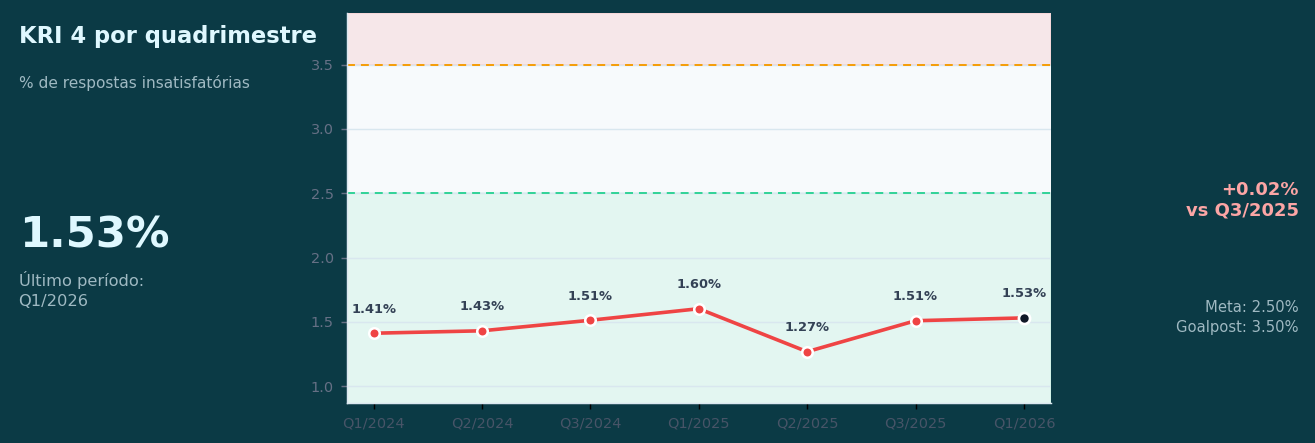

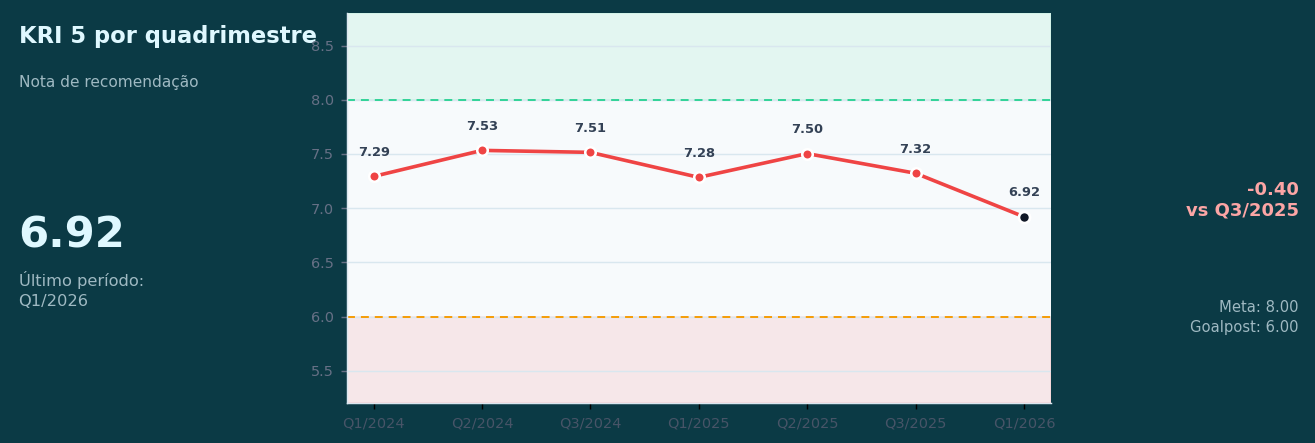

,indicador,caminho
0,KRI 1 por quadrimestre,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
1,KRI 2 por quadrimestre,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
2,KRI 3 por quadrimestre,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
3,KRI 4 por quadrimestre,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
4,KRI 5 por quadrimestre,C:\Users\andre\OneDrive\Claude-Work\Projects\i...


In [10]:
def plotar_grafico_kri(
    df: pd.DataFrame,
    coluna: str,
    titulo: str,
    subtitulo: str,
    nome_arquivo: str,
    meta: float,
    goalpost: float,
    percentual: bool = False,
    menor_melhor: bool = False,
) -> Path:
    dados = df[["quadri_label", coluna]].copy()
    fator = 100 if percentual else 1
    dados["valor_plot"] = dados[coluna] * fator
    meta_plot = meta * fator
    goal_plot = goalpost * fator
    x = np.arange(len(dados))
    y = dados["valor_plot"].to_numpy()

    fig = plt.figure(figsize=(12.8, 3.9), facecolor=C_BG)
    gs = fig.add_gridspec(1, 3, width_ratios=GRID_RATIOS, wspace=0.14)
    ax_l = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[0, 1])
    ax_r = fig.add_subplot(gs[0, 2])

    for eixo in (ax_l, ax_r):
        eixo.set_facecolor(C_BG)
        eixo.set_xticks([])
        eixo.set_yticks([])
        for spine in eixo.spines.values():
            spine.set_visible(False)

    valor_atual = float(y[-1])
    valor_anterior = float(y[-2]) if len(y) > 1 else np.nan
    delta = valor_atual - valor_anterior if len(y) > 1 else np.nan
    unidade = "%" if percentual else ""
    fmt = lambda v: f"{v:.2f}{unidade}"

    titulo_fmt = quebrar_texto(titulo, 24)
    subtitulo_fmt = quebrar_texto(subtitulo, 32)
    ax_l.text(0.02, 0.97, titulo_fmt, color=C_TEXT, fontsize=12.5, fontweight="bold", va="top", transform=ax_l.transAxes)
    ax_l.text(0.02, 0.84, subtitulo_fmt, color=C_MUTED, fontsize=8.5, va="top", transform=ax_l.transAxes)
    ax_l.text(0.02, 0.40, fmt(valor_atual), color=C_TEXT, fontsize=24, fontweight="bold", transform=ax_l.transAxes)
    ax_l.text(0.02, 0.25, f"Último período:\n{dados['quadri_label'].iloc[-1]}", color=C_MUTED, fontsize=9, linespacing=1.4, transform=ax_l.transAxes)

    ax.set_facecolor(C_PANEL)
    ymin = min(y.min(), meta_plot, goal_plot)
    ymax = max(y.max(), meta_plot, goal_plot)
    pad = max((ymax - ymin) * 0.18, 0.8 if not percentual else 0.15)
    low = max(0, ymin - pad)
    high = ymax + pad
    if menor_melhor:
        ax.axhspan(goal_plot, high, color="#ef4444", alpha=0.10)
        ax.axhspan(0, meta_plot, color="#34d399", alpha=0.10)
    else:
        ax.axhspan(low, goal_plot, color="#ef4444", alpha=0.10)
        ax.axhspan(meta_plot, high, color="#34d399", alpha=0.10)
    ax.axhline(meta_plot, color="#34d399", linestyle=(0, (4, 3)), linewidth=1.1)
    ax.axhline(goal_plot, color="#f59e0b", linestyle=(0, (4, 3)), linewidth=1.1)
    ax.plot(x, y, color="#ef4444", linewidth=2)
    ax.scatter(x[:-1], y[:-1], color="#ef4444", edgecolor="white", linewidth=1.4, s=34, zorder=3)
    ax.scatter(x[-1], y[-1], color=C_DOT_FINAL, edgecolor="white", linewidth=1.5, s=38, zorder=4)

    for xi, yi in zip(x, y):
        ax.text(xi, yi + (high - low) * 0.045, fmt(yi), ha="center", va="bottom", fontsize=7.2, color="#334155", fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(dados["quadri_label"], fontsize=8, color="#475467")
    ax.tick_params(axis="y", labelsize=8, colors="#667085")
    ax.grid(axis="y", color=C_GRID, linewidth=0.8)
    ax.set_ylim(low, high)
    ax.set_xlim(-0.25, len(dados) - 0.75)
    ax.spines["left"].set_color("#dbe7f0")
    ax.spines["bottom"].set_color("#dbe7f0")

    if not math.isnan(delta):
        sinal = "+" if delta >= 0 else ""
        cor_delta = "#86efac" if ((delta <= 0) and menor_melhor) or ((delta >= 0) and (not menor_melhor)) else "#fca5a5"
        ax_r.text(0.98, 0.52, f"{sinal}{delta:.2f}{unidade}\nvs {dados['quadri_label'].iloc[-2]}", ha="right", va="center", fontsize=10, fontweight="bold", color=cor_delta, transform=ax_r.transAxes)
    ax_r.text(0.98, 0.22, f"Meta: {fmt(meta_plot)}\nGoalpost: {fmt(goal_plot)}", ha="right", va="center", fontsize=8.2, color=C_MUTED, linespacing=1.45, transform=ax_r.transAxes)

    caminho = SAIDA / nome_arquivo
    fig.savefig(caminho, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    plt.close(fig)
    return caminho


kri_configs = [
    {
        "coluna": "kri1_pct_mais_30",
        "titulo": "KRI 1 por quadrimestre",
        "subtitulo": "% de manifestações com mais de 30 dias",
        "nome_arquivo": "kri1_pct_mais_30_por_quadrimestre.png",
        "meta": 0.01,
        "goalpost": 0.02,
        "percentual": True,
        "menor_melhor": True,
    },
    {
        "coluna": "tmr",
        "titulo": "KRI 2 por quadrimestre",
        "subtitulo": "Tempo médio de resposta (dias)",
        "nome_arquivo": "kri2_tmr_por_quadrimestre.png",
        "meta": 5.0,
        "goalpost": 10.0,
        "percentual": False,
        "menor_melhor": True,
    },
    {
        "coluna": "kri3_resolutividade",
        "titulo": "KRI 3 por quadrimestre",
        "subtitulo": "Resolutividade",
        "nome_arquivo": "kri3_resolutividade_por_quadrimestre.png",
        "meta": 0.70,
        "goalpost": 0.50,
        "percentual": True,
        "menor_melhor": False,
    },
    {
        "coluna": "kri4_pct_insatisfatorias",
        "titulo": "KRI 4 por quadrimestre",
        "subtitulo": "% de respostas insatisfatórias",
        "nome_arquivo": "kri4_pct_insatisfatorias_por_quadrimestre.png",
        "meta": 0.025,
        "goalpost": 0.035,
        "percentual": True,
        "menor_melhor": True,
    },
    {
        "coluna": "kri5_nota",
        "titulo": "KRI 5 por quadrimestre",
        "subtitulo": "Nota de recomendação",
        "nome_arquivo": "kri5_nota_recomendacao_por_quadrimestre.png",
        "meta": 8.0,
        "goalpost": 6.0,
        "percentual": False,
        "menor_melhor": False,
    },
]

arquivos_kri = []
for cfg in kri_configs:
    caminho = plotar_grafico_kri(serie_quadri, **cfg)
    arquivos_kri.append({"indicador": cfg["titulo"], "caminho": str(caminho)})

pd.DataFrame(arquivos_kri)

## 5. Exportação

Além dos PNGs, a tabela consolidada da série também é salva em CSV para reuso em relatórios e validações.

In [11]:
csv_saida = SAIDA / "serie_quadrimestral_igro.csv"
serie_exportacao.round(4).to_csv(csv_saida, index=False, encoding="utf-8-sig")

pd.DataFrame(
    {
        "artefato": [
            "Gráfico IGRO",
            "Gráfico Sub-T",
            "Gráfico Sub-Q",
            "Gráficos KRI 1 a KRI 5",
            "CSV da série quadrimestral",
        ],
        "caminho": [str(arquivo_igro), str(arquivo_subt), str(arquivo_subq), str(SAIDA), str(csv_saida)],
    }
)

,artefato,caminho
0,Gráfico IGRO,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
1,Gráfico Sub-T,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
2,Gráfico Sub-Q,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
3,Gráficos KRI 1 a KRI 5,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
4,CSV da série quadrimestral,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
